# Machine Learning Pipeline - Bestseller Prediction

## Quy trình chuẩn:
1. **Chia dữ liệu**: Train (60%) - Validation (20%) - Test (20%)
2. **Scaling & SMOTE**: Chỉ fit trên Train, transform tất cả
3. **GridSearch/CV**: Tìm hyperparameters tốt nhất trên Train
4. **Chọn model**: Dựa trên kết quả Validation
5. **Train lại**: Với best params trên Train + Validation
6. **Đánh giá cuối**: Chỉ 1 lần duy nhất trên Test


## 1. Import Libraries


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Visualization settings
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)


## 2. Load Data


In [15]:
df = pd.read_csv('data_final_preprocessed.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['is_bestseller'].value_counts())
print(f"\nImbalance ratio: {(df['is_bestseller']==0).sum() / (df['is_bestseller']==1).sum():.2f}:1")


Dataset shape: (9760, 19)

Class distribution:
is_bestseller
0    7509
1    2251
Name: count, dtype: int64

Imbalance ratio: 3.34:1


In [16]:
# Tách X và y
X = df.drop(columns=['is_bestseller'])
y = df['is_bestseller']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")


Features: 18
Samples: 9760


## 3. Train-Validation-Test Split

**Quy trình:**
- Train: 60% - Dùng để huấn luyện và GridSearch
- Validation: 20% - Dùng để chọn model tốt nhất
- Test: 20% - Giữ hoàn toàn tách biệt, chỉ đánh giá 1 lần cuối


In [17]:
# Bước 1: Tách Test set (20%) ra trước - GIỮ HOÀN TOÀN TÁCH BIỆT
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Bước 2: Tách Train và Validation từ phần còn lại
# Train: 75% của 80% = 60% tổng
# Validation: 25% của 80% = 20% tổng
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print("=" * 80)
print("PHÂN CHIA DỮ LIỆU")
print("=" * 80)
print(f"\nTrain set:      {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_valid.shape[0]:,} samples ({X_valid.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain+Valid:    {X_trainval.shape[0]:,} samples ({X_trainval.shape[0]/len(X)*100:.1f}%)")

print(f"\n" + "=" * 80)
print("PHÂN BỐ CLASS")
print("=" * 80)
for name, y_set in [('Train', y_train), ('Validation', y_valid), ('Test', y_test)]:
    n0, n1 = (y_set==0).sum(), (y_set==1).sum()
    print(f"{name:12s}: Class 0 = {n0:,} ({n0/len(y_set)*100:.1f}%) | Class 1 = {n1:,} ({n1/len(y_set)*100:.1f}%)")


PHÂN CHIA DỮ LIỆU

Train set:      5,856 samples (60.0%)
Validation set: 1,952 samples (20.0%)
Test set:       1,952 samples (20.0%)

Train+Valid:    7,808 samples (80.0%)

PHÂN BỐ CLASS
Train       : Class 0 = 4,505 (76.9%) | Class 1 = 1,351 (23.1%)
Validation  : Class 0 = 1,502 (76.9%) | Class 1 = 450 (23.1%)
Test        : Class 0 = 1,502 (76.9%) | Class 1 = 450 (23.1%)


## 4. Preprocessing: Scaling

**Quan trọng:** Fit scaler CHỈ trên Train set để tránh data leakage


In [18]:
# Khởi tạo và fit scaler CHỈ trên Train set
scaler = RobustScaler()
scaler.fit(X_train)

# Transform tất cả các tập
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Scale cả trainval để dùng cho bước train lại sau
X_trainval_scaled = pd.DataFrame(
    scaler.transform(X_trainval),
    columns=X_trainval.columns,
    index=X_trainval.index
)

print("✓ Đã hoàn thành Scaling với RobustScaler")
print(f"  - Scaler fit trên: Train set ({X_train.shape[0]:,} samples)")
print(f"  - Transform: Train, Validation, Test, TrainVal")


✓ Đã hoàn thành Scaling với RobustScaler
  - Scaler fit trên: Train set (5,856 samples)
  - Transform: Train, Validation, Test, TrainVal


## 5. Preprocessing: SMOTE (Handle Class Imbalance)

**Quan trọng:** SMOTE CHỈ áp dụng trên Train set


In [19]:
print("SMOTE - Xử lý Class Imbalance")
print("=" * 80)

# SMOTE cho Train set
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nTrain set:")
print(f"  Before SMOTE: {X_train_scaled.shape[0]:,} samples")
print(f"  After SMOTE:  {X_train_resampled.shape[0]:,} samples")
print(f"  Added: {X_train_resampled.shape[0] - X_train_scaled.shape[0]:,} synthetic samples")

print(f"\n  Class distribution after SMOTE:")
print(f"    Class 0: {(y_train_resampled==0).sum():,} ({(y_train_resampled==0).sum()/len(y_train_resampled)*100:.1f}%)")
print(f"    Class 1: {(y_train_resampled==1).sum():,} ({(y_train_resampled==1).sum()/len(y_train_resampled)*100:.1f}%)")

# SMOTE cho TrainVal set (sẽ dùng sau khi chọn model tốt nhất)
smote_trainval = SMOTE(random_state=42, sampling_strategy=0.5)
X_trainval_resampled, y_trainval_resampled = smote_trainval.fit_resample(X_trainval_scaled, y_trainval)

print(f"\nTrain+Validation set (cho bước train lại):")
print(f"  Before SMOTE: {X_trainval_scaled.shape[0]:,} samples")
print(f"  After SMOTE:  {X_trainval_resampled.shape[0]:,} samples")


SMOTE - Xử lý Class Imbalance

Train set:
  Before SMOTE: 5,856 samples
  After SMOTE:  6,757 samples
  Added: 901 synthetic samples

  Class distribution after SMOTE:
    Class 0: 4,505 (66.7%)
    Class 1: 2,252 (33.3%)

Train+Validation set (cho bước train lại):
  Before SMOTE: 7,808 samples
  After SMOTE:  9,010 samples


In [20]:
# Chuẩn bị dữ liệu cuối cùng
X_train_final = pd.DataFrame(X_train_resampled, columns=X_train_scaled.columns)
y_train_final = pd.Series(y_train_resampled)

X_valid_final = X_valid_scaled.copy()
y_valid_final = y_valid.copy()

X_test_final = X_test_scaled.copy()
y_test_final = y_test.copy()

X_trainval_final = pd.DataFrame(X_trainval_resampled, columns=X_trainval_scaled.columns)
y_trainval_final = pd.Series(y_trainval_resampled)

print("✓ Dữ liệu đã sẵn sàng:")
print(f"  - X_train_final:    {X_train_final.shape}")
print(f"  - X_valid_final:    {X_valid_final.shape}")
print(f"  - X_test_final:     {X_test_final.shape}")
print(f"  - X_trainval_final: {X_trainval_final.shape}")


✓ Dữ liệu đã sẵn sàng:
  - X_train_final:    (6757, 18)
  - X_valid_final:    (1952, 18)
  - X_test_final:     (1952, 18)
  - X_trainval_final: (9010, 18)


## 6. Baseline Models - Đánh giá nhanh


In [21]:
# Định nghĩa các models với default parameters
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=100, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}


In [22]:
# Train và đánh giá baseline models
baseline_results = {}

print("=" * 80)
print("BASELINE MODELS - ĐÁNH GIÁ TRÊN VALIDATION SET")
print("=" * 80)

for name, model in models.items():
    start_time = time.time()

    try:
        # Train trên Train set
        model.fit(X_train_final, y_train_final)

        # Đánh giá trên Validation set
        y_pred = model.predict(X_valid_final)
        y_pred_proba = model.predict_proba(X_valid_final)[:, 1]

        train_time = time.time() - start_time

        baseline_results[name] = {
            'Accuracy': accuracy_score(y_valid_final, y_pred),
            'Precision': precision_score(y_valid_final, y_pred),
            'Recall': recall_score(y_valid_final, y_pred),
            'F1-Score': f1_score(y_valid_final, y_pred),
            'ROC-AUC': roc_auc_score(y_valid_final, y_pred_proba),
            'Training Time': train_time
        }

        print(f"\n{name}:")
        print(f"  F1-Score: {baseline_results[name]['F1-Score']:.4f} | ROC-AUC: {baseline_results[name]['ROC-AUC']:.4f}")

    except Exception as e:
        print(f"\n{name}: LỖI - {str(e)}")

print("\n" + "=" * 80)


BASELINE MODELS - ĐÁNH GIÁ TRÊN VALIDATION SET

Logistic Regression:
  F1-Score: 0.6010 | ROC-AUC: 0.8401

Decision Tree:
  F1-Score: 0.7156 | ROC-AUC: 0.8790

Random Forest:
  F1-Score: 0.7723 | ROC-AUC: 0.9411

Gradient Boosting:
  F1-Score: 0.7203 | ROC-AUC: 0.9140

XGBoost:
  F1-Score: 0.7618 | ROC-AUC: 0.9327

LightGBM:
  F1-Score: 0.7485 | ROC-AUC: 0.9342

AdaBoost:
  F1-Score: 0.6392 | ROC-AUC: 0.8738

K-Nearest Neighbors:
  F1-Score: 0.6957 | ROC-AUC: 0.8885

Naive Bayes:
  F1-Score: 0.5010 | ROC-AUC: 0.7768

Support Vector Machine:
  F1-Score: 0.6069 | ROC-AUC: 0.8417



In [23]:
# Tạo bảng so sánh baseline
baseline_df = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'Accuracy': [baseline_results[m]['Accuracy'] for m in baseline_results],
    'Precision': [baseline_results[m]['Precision'] for m in baseline_results],
    'Recall': [baseline_results[m]['Recall'] for m in baseline_results],
    'F1-Score': [baseline_results[m]['F1-Score'] for m in baseline_results],
    'ROC-AUC': [baseline_results[m]['ROC-AUC'] for m in baseline_results],
    'Time (s)': [baseline_results[m]['Training Time'] for m in baseline_results]
})

baseline_df = baseline_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nBẢNG XẾP HẠNG BASELINE MODELS (theo F1-Score trên Validation):")
print("=" * 100)
print(baseline_df.to_string(index=False))
print("=" * 100)

# Chọn top 5 để tuning
top_5_models = baseline_df.head(5)['Model'].tolist()
print(f"\n→ Top 5 models cho GridSearch: {top_5_models}")



BẢNG XẾP HẠNG BASELINE MODELS (theo F1-Score trên Validation):
                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)
         Random Forest  0.905738   0.871508 0.693333  0.772277 0.941118  2.026791
               XGBoost  0.899078   0.835544 0.700000  0.761790 0.932718  0.215708
              LightGBM  0.893955   0.825737 0.684444  0.748481 0.934249  0.229161
     Gradient Boosting  0.877049   0.757353 0.686667  0.720280 0.914041  2.522771
         Decision Tree  0.872951   0.739336 0.693333  0.715596 0.879033  0.134051
   K-Nearest Neighbors  0.856557   0.680851 0.711111  0.695652 0.888485  0.113841
              AdaBoost  0.824795   0.608434 0.673333  0.639241 0.873782  1.067242
Support Vector Machine  0.806865   0.571709 0.646667  0.606882 0.841719  6.436148
   Logistic Regression  0.804816   0.568317 0.637778  0.601047 0.840080  0.284080
           Naive Bayes  0.755123   0.472441 0.533333  0.501044 0.776778  0.005374

→ Top 5 models cho GridSearch: ['

## 7. Hyperparameter Tuning - GridSearch


In [24]:
# Định nghĩa parameter grids cho TOP 5 MODELS
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2', 0.8],
            'class_weight': [None, 'balanced'],
            'ccp_alpha': [0.0, 0.001],
            'min_impurity_decrease': [0.0, 1e-3]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1, n_jobs=1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 15],
            'learning_rate': [0.05, 0.1],
            'num_leaves': [31, 50],
            'feature_fraction': [0.8, 1.0],
            'bagging_fraction': [0.8, 1.0],
            'bagging_freq': [0, 1],
            'min_child_samples': [20, 40],
            'min_split_gain': [0.0, 0.1],
            'reg_alpha': [0.0, 0.1],
            'reg_lambda': [0.0, 0.1]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 7],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 1],
            'reg_alpha': [0, 0.1],
            'reg_lambda': [1, 2]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
            'max_depth': [3, 5],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2', None],
            'min_impurity_decrease': [0.0, 1e-3]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'criterion': ['gini', 'entropy', 'log_loss'],
            'max_features': [None, 'sqrt', 'log2'],
            'ccp_alpha': [0.0, 0.001, 0.01],
            'min_impurity_decrease': [0.0, 1e-3]
        }
    },
}

print("✓ Đã định nghĩa parameter grids cho 5 models tốt nhất")


✓ Đã định nghĩa parameter grids cho 5 models tốt nhất


In [25]:
# Thực hiện GridSearch cho top 5 models
gridsearch_results = {}
best_models = {}

print("=" * 80)
print("GRIDSEARCH - TÌM HYPERPARAMETERS TỐT NHẤT")
print("=" * 80)

for model_name in top_5_models:
    if model_name not in param_grids:
        print(f"\n⚠️ Không có param_grid cho {model_name}")
        continue

    print(f"\n{'='*80}")
    print(f"GridSearch: {model_name}")
    print(f"{'='*80}")

    model_info = param_grids[model_name]
    model = model_info['model']
    params = model_info['params']

    start_time = time.time()

    try:
        # GridSearchCV với 5-fold CV trên Train set
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=5,
            scoring='f1',
            n_jobs=-1,
            verbose=1,
            return_train_score=True
        )

        grid_search.fit(X_train_final, y_train_final)

        train_time = time.time() - start_time

        gridsearch_results[model_name] = {
            'best_model': grid_search.best_estimator_,
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'training_time': train_time
        }

        best_models[model_name] = grid_search.best_estimator_

        print(f"\n✓ Best CV F1-Score: {grid_search.best_score_:.4f}")
        print(f"  Training Time: {train_time:.2f}s")
        print(f"  Best Parameters: {grid_search.best_params_}")

    except Exception as e:
        print(f"  ❌ LỖI: {str(e)}")

print(f"\n{'='*80}")
print("✓ HOÀN THÀNH GRIDSEARCH")
print(f"{'='*80}")


GRIDSEARCH - TÌM HYPERPARAMETERS TỐT NHẤT

GridSearch: Random Forest
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

✓ Best CV F1-Score: 0.8547
  Training Time: 4517.59s
  Best Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 15, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

GridSearch: XGBoost
Fitting 5 folds for each of 768 candidates, totalling 3840 fits

✓ Best CV F1-Score: 0.8589
  Training Time: 891.58s
  Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}

GridSearch: LightGBM
Fitting 5 folds for each of 2048 candidates, totalling 10240 fits

✓ Best CV F1-Score: 0.8585
  Training Time: 2915.18s
  Best Parameters: {'bagging_fraction': 0.8, 'bagging_freq': 0, 'feature_fraction': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_sam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 8. Đánh giá trên Validation Set - Chọn Model Tốt Nhất


In [26]:
# Đánh giá các tuned models trên Validation set
validation_results = {}

print("=" * 80)
print("ĐÁNH GIÁ TRÊN VALIDATION SET")
print("=" * 80)

for model_name, model in best_models.items():
    y_pred = model.predict(X_valid_final)
    y_pred_proba = model.predict_proba(X_valid_final)[:, 1]

    validation_results[model_name] = {
        'Accuracy': accuracy_score(y_valid_final, y_pred),
        'Precision': precision_score(y_valid_final, y_pred),
        'Recall': recall_score(y_valid_final, y_pred),
        'F1-Score': f1_score(y_valid_final, y_pred),
        'ROC-AUC': roc_auc_score(y_valid_final, y_pred_proba),
        'CV F1-Score': gridsearch_results[model_name]['best_cv_score']
    }

    print(f"\n{model_name}:")
    print(f"  Valid F1: {validation_results[model_name]['F1-Score']:.4f} | CV F1: {validation_results[model_name]['CV F1-Score']:.4f}")


ĐÁNH GIÁ TRÊN VALIDATION SET

Random Forest:
  Valid F1: 0.7736 | CV F1: 0.8547

XGBoost:
  Valid F1: 0.7687 | CV F1: 0.8589

LightGBM:
  Valid F1: 0.7656 | CV F1: 0.8585

Gradient Boosting:
  Valid F1: 0.7698 | CV F1: 0.8497

Decision Tree:
  Valid F1: 0.7130 | CV F1: 0.8046


In [27]:
# Bảng so sánh và chọn model tốt nhất
validation_df = pd.DataFrame({
    'Model': list(validation_results.keys()),
    'CV F1-Score': [validation_results[m]['CV F1-Score'] for m in validation_results],
    'Valid Accuracy': [validation_results[m]['Accuracy'] for m in validation_results],
    'Valid Precision': [validation_results[m]['Precision'] for m in validation_results],
    'Valid Recall': [validation_results[m]['Recall'] for m in validation_results],
    'Valid F1-Score': [validation_results[m]['F1-Score'] for m in validation_results],
    'Valid ROC-AUC': [validation_results[m]['ROC-AUC'] for m in validation_results]
})

validation_df = validation_df.sort_values('Valid F1-Score', ascending=False).reset_index(drop=True)

print("\nBẢNG XẾP HẠNG SAU TUNING (theo Validation F1-Score):")
print("=" * 110)
print(validation_df.to_string(index=False))
print("=" * 110)

# Chọn model tốt nhất
BEST_MODEL_NAME = validation_df.iloc[0]['Model']
BEST_VALID_F1 = validation_df.iloc[0]['Valid F1-Score']

print(f"\n🏆 MODEL TỐT NHẤT: {BEST_MODEL_NAME}")
print(f"   Validation F1-Score: {BEST_VALID_F1:.4f}")



BẢNG XẾP HẠNG SAU TUNING (theo Validation F1-Score):
            Model  CV F1-Score  Valid Accuracy  Valid Precision  Valid Recall  Valid F1-Score  Valid ROC-AUC
    Random Forest     0.854667        0.906762         0.878531      0.691111        0.773632       0.941322
Gradient Boosting     0.849740        0.900102         0.821159      0.724444        0.769776       0.935548
          XGBoost     0.858863        0.901639         0.839474      0.708889        0.768675       0.936519
         LightGBM     0.858536        0.902152         0.854795      0.693333        0.765644       0.938411
    Decision Tree     0.804557        0.866803         0.708333      0.717778        0.713024       0.839692

🏆 MODEL TỐT NHẤT: Random Forest
   Validation F1-Score: 0.7736


## 9. Train lại Model Tốt Nhất trên Train + Validation

**Bước quan trọng:** Sau khi chọn được model và hyperparameters tốt nhất, train lại model trên toàn bộ dữ liệu huấn luyện mở rộng (Train + Validation) để tận dụng tối đa dữ liệu trước khi đánh giá cuối cùng trên Test.


In [28]:
print("=" * 80)
print("TRAIN LẠI MODEL TRÊN TRAIN + VALIDATION")
print("=" * 80)

# Lấy best parameters
best_params = gridsearch_results[BEST_MODEL_NAME]['best_params']
print(f"\nModel: {BEST_MODEL_NAME}")
print(f"Best Parameters: {best_params}")

# Tạo model mới với best parameters
if BEST_MODEL_NAME == 'Random Forest':
    final_model = RandomForestClassifier(random_state=42, **best_params)
elif BEST_MODEL_NAME == 'XGBoost':
    final_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', **best_params)
elif BEST_MODEL_NAME == 'LightGBM':
    final_model = LGBMClassifier(random_state=42, verbose=-1, **best_params)
elif BEST_MODEL_NAME == 'Gradient Boosting':
    final_model = GradientBoostingClassifier(random_state=42, **best_params)
elif BEST_MODEL_NAME == 'Decision Tree':
    final_model = DecisionTreeClassifier(random_state=42, **best_params)
elif BEST_MODEL_NAME == 'Logistic Regression':
    final_model = LogisticRegression(random_state=42, max_iter=1000, **best_params)
elif BEST_MODEL_NAME == 'K-Nearest Neighbors':
    final_model = KNeighborsClassifier(**best_params)
elif BEST_MODEL_NAME == 'Support Vector Machine':
    final_model = SVC(random_state=42, probability=True, **best_params)
elif BEST_MODEL_NAME == 'AdaBoost':
    final_model = AdaBoostClassifier(random_state=42, **best_params)
else:
    raise ValueError(f"Unknown model: {BEST_MODEL_NAME}")

# Train trên Train + Validation (đã SMOTE)
print(f"\nTraining trên Train+Validation: {X_trainval_final.shape[0]:,} samples")
start_time = time.time()
final_model.fit(X_trainval_final, y_trainval_final)
train_time = time.time() - start_time

print(f"✓ Hoàn thành training trong {train_time:.2f}s")
print("=" * 80)


TRAIN LẠI MODEL TRÊN TRAIN + VALIDATION

Model: Random Forest
Best Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 15, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Training trên Train+Validation: 9,010 samples
✓ Hoàn thành training trong 3.91s


## 10. Đánh giá Cuối Cùng trên Test Set

**Chỉ đánh giá 1 lần duy nhất** trên Test set để đảm bảo tính khách quan.


In [29]:
print("=" * 80)
print("ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET")
print("=" * 80)

# Dự đoán trên Test set
y_test_pred = final_model.predict(X_test_final)
y_test_pred_proba = final_model.predict_proba(X_test_final)[:, 1]

# Tính metrics
test_metrics = {
    'Accuracy': accuracy_score(y_test_final, y_test_pred),
    'Precision': precision_score(y_test_final, y_test_pred),
    'Recall': recall_score(y_test_final, y_test_pred),
    'F1-Score': f1_score(y_test_final, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test_final, y_test_pred_proba)
}

print(f"\nModel: {BEST_MODEL_NAME}")
print(f"Trained on: Train + Validation ({X_trainval_final.shape[0]:,} samples)")
print(f"Evaluated on: Test ({X_test_final.shape[0]:,} samples)")

print(f"\n" + "-" * 40)
print("KẾT QUẢ CUỐI CÙNG:")
print("-" * 40)
print(f"  Accuracy:  {test_metrics['Accuracy']:.4f}")
print(f"  Precision: {test_metrics['Precision']:.4f}")
print(f"  Recall:    {test_metrics['Recall']:.4f}")
print(f"  F1-Score:  {test_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC:   {test_metrics['ROC-AUC']:.4f}")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test_final, y_test_pred)
print(f"  TN: {cm[0,0]:5d}  |  FP: {cm[0,1]:5d}")
print(f"  FN: {cm[1,0]:5d}  |  TP: {cm[1,1]:5d}")

print(f"\nClassification Report:")
print(classification_report(y_test_final, y_test_pred, target_names=['Not Bestseller', 'Bestseller']))
print("=" * 80)


ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET

Model: Random Forest
Trained on: Train + Validation (9,010 samples)
Evaluated on: Test (1,952 samples)

----------------------------------------
KẾT QUẢ CUỐI CÙNG:
----------------------------------------
  Accuracy:  0.9160
  Precision: 0.8763
  Recall:    0.7400
  F1-Score:  0.8024
  ROC-AUC:   0.9518

Confusion Matrix:
  TN:  1455  |  FP:    47
  FN:   117  |  TP:   333

Classification Report:
                precision    recall  f1-score   support

Not Bestseller       0.93      0.97      0.95      1502
    Bestseller       0.88      0.74      0.80       450

      accuracy                           0.92      1952
     macro avg       0.90      0.85      0.87      1952
  weighted avg       0.91      0.92      0.91      1952



In [30]:
# So sánh hiệu suất qua các giai đoạn
print("\n" + "=" * 80)
print("SO SÁNH HIỆU SUẤT QUA CÁC GIAI ĐOẠN")
print("=" * 80)

# Đánh giá trên Train+Valid để kiểm tra overfitting
y_trainval_pred = final_model.predict(X_trainval_final)
y_trainval_pred_proba = final_model.predict_proba(X_trainval_final)[:, 1]

trainval_f1 = f1_score(y_trainval_final, y_trainval_pred)
trainval_auc = roc_auc_score(y_trainval_final, y_trainval_pred_proba)

comparison_data = {
    'Stage': ['Cross-Validation (5-fold)', 'Validation Set', 'Train+Valid Set', 'Test Set (Final)'],
    'F1-Score': [
        gridsearch_results[BEST_MODEL_NAME]['best_cv_score'],
        validation_results[BEST_MODEL_NAME]['F1-Score'],
        trainval_f1,
        test_metrics['F1-Score']
    ],
    'Note': [
        'Trên Train set',
        'Model train trên Train',
        'Model train trên Train+Valid',
        'Model train trên Train+Valid'
    ]
}

comparison_stages = pd.DataFrame(comparison_data)
print(comparison_stages.to_string(index=False))

print(f"\n" + "-" * 80)
print("PHÂN TÍCH:")
print("-" * 80)
gap = trainval_f1 - test_metrics['F1-Score']
print(f"  Train+Valid F1: {trainval_f1:.4f}")
print(f"  Test F1:        {test_metrics['F1-Score']:.4f}")
print(f"  Gap:            {gap*100:.2f}%")

if gap > 0.15:
    print("\n  ⚠️ Có dấu hiệu overfitting đáng kể (gap > 15%)")
elif gap > 0.05:
    print("\n  ⚠️ Có dấu hiệu overfitting nhẹ (gap > 5%)")
else:
    print("\n  ✓ Model generalize tốt (gap ≤ 5%)")
print("=" * 80)



SO SÁNH HIỆU SUẤT QUA CÁC GIAI ĐOẠN
                    Stage  F1-Score                         Note
Cross-Validation (5-fold)  0.854667               Trên Train set
           Validation Set  0.773632       Model train trên Train
          Train+Valid Set  0.996659 Model train trên Train+Valid
         Test Set (Final)  0.802410 Model train trên Train+Valid

--------------------------------------------------------------------------------
PHÂN TÍCH:
--------------------------------------------------------------------------------
  Train+Valid F1: 0.9967
  Test F1:        0.8024
  Gap:            19.42%

  ⚠️ Có dấu hiệu overfitting đáng kể (gap > 15%)


## 11. Visualizations


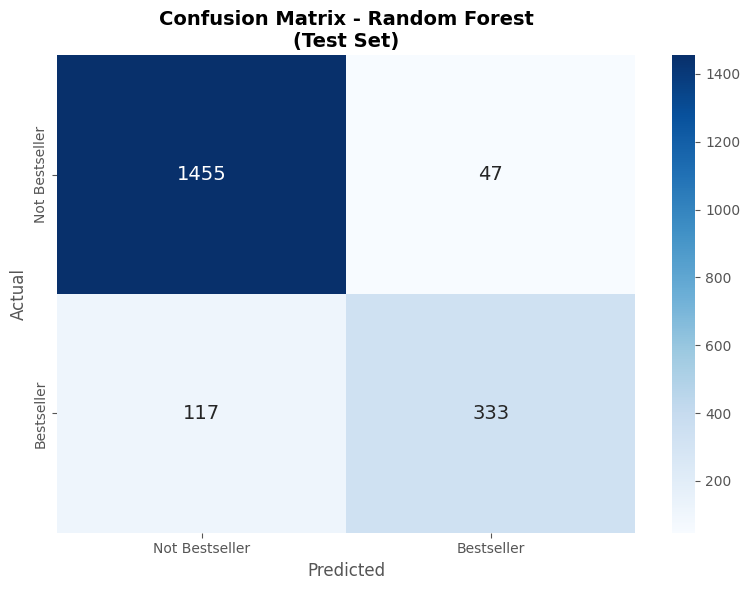

In [31]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Bestseller', 'Bestseller'],
            yticklabels=['Not Bestseller', 'Bestseller'],
            annot_kws={'size': 14})

ax.set_title(f'Confusion Matrix - {BEST_MODEL_NAME}\n(Test Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()


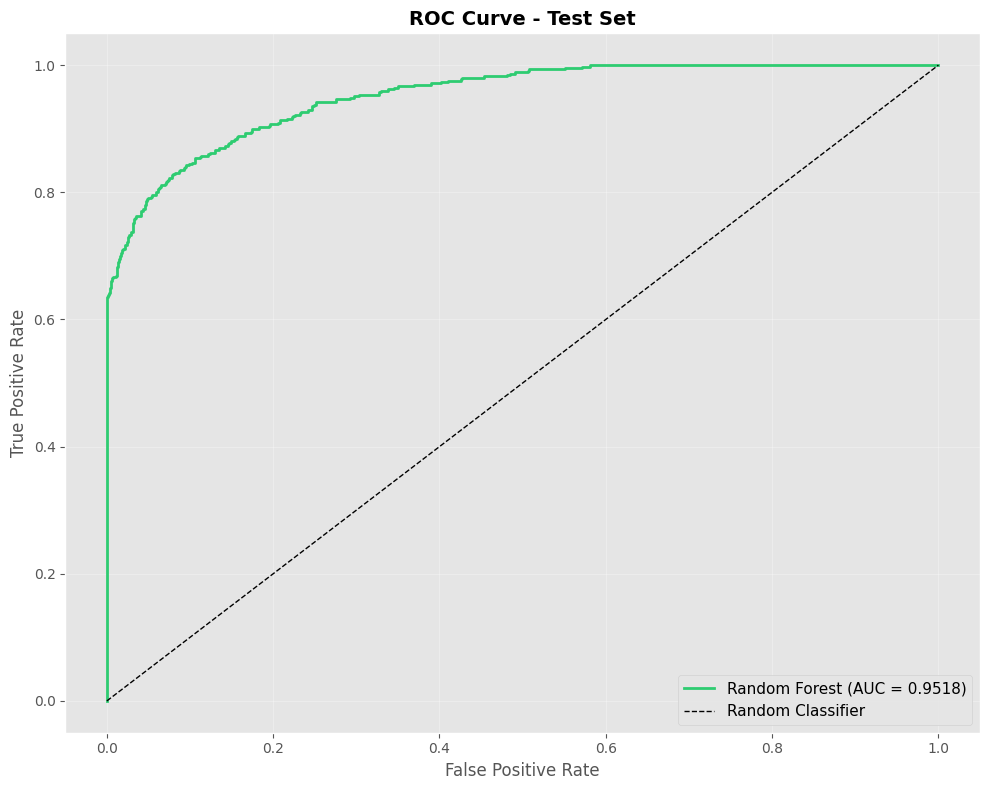

In [32]:
# ROC Curve
fig, ax = plt.subplots(figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test_final, y_test_pred_proba)
ax.plot(fpr, tpr, label=f'{BEST_MODEL_NAME} (AUC = {test_metrics["ROC-AUC"]:.4f})',
        color='#2ecc71', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve - Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


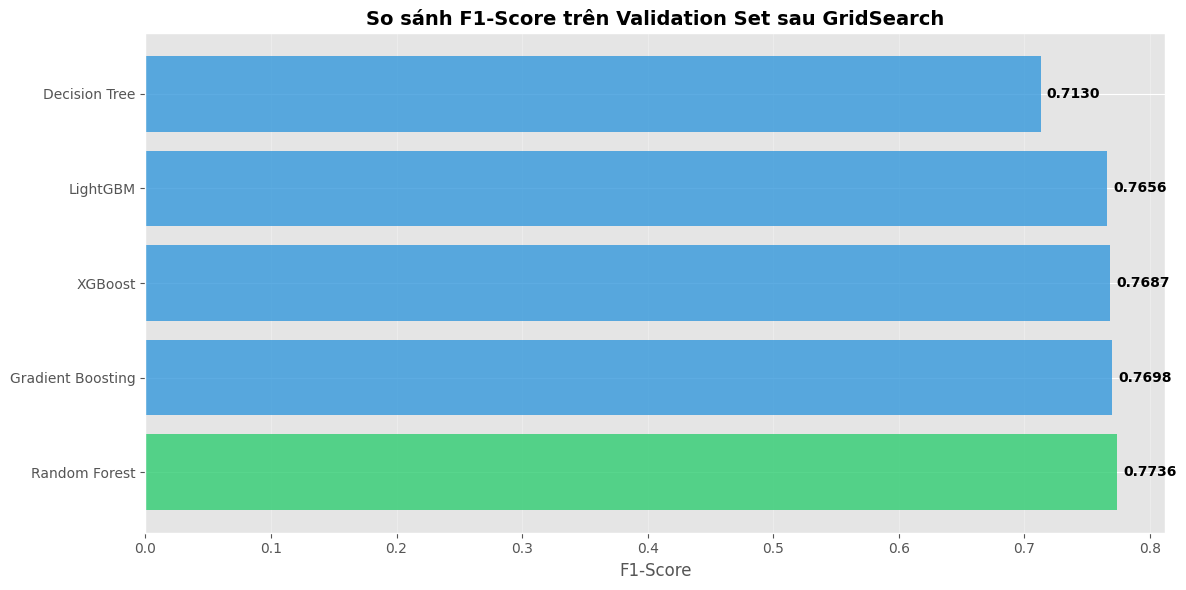

In [33]:
# So sánh F1-Score của các models sau tuning
fig, ax = plt.subplots(figsize=(12, 6))

models_list = validation_df['Model'].tolist()
f1_scores = validation_df['Valid F1-Score'].tolist()

colors = ['#2ecc71' if m == BEST_MODEL_NAME else '#3498db' for m in models_list]
bars = ax.barh(models_list, f1_scores, color=colors, alpha=0.8)

for i, (model, score) in enumerate(zip(models_list, f1_scores)):
    ax.text(score + 0.005, i, f'{score:.4f}', va='center', fontweight='bold')

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('So sánh F1-Score trên Validation Set sau GridSearch', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Lưu Model và Artifacts


In [34]:
# Lưu model cuối cùng
model_filename = f'best_model_{BEST_MODEL_NAME.replace(" ", "_")}_final.pkl'
joblib.dump(final_model, model_filename)

# Lưu scaler
joblib.dump(scaler, 'scaler_final.pkl')

# Lưu feature names
with open('feature_names.json', 'w', encoding='utf-8') as f:
    json.dump(X.columns.tolist(), f, indent=2)

# Lưu best parameters và kết quả
results_to_save = {
    'model_name': BEST_MODEL_NAME,
    'best_parameters': best_params,
    'cv_f1_score': float(gridsearch_results[BEST_MODEL_NAME]['best_cv_score']),
    'validation_f1_score': float(validation_results[BEST_MODEL_NAME]['F1-Score']),
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'data_split': {
        'train_samples': int(X_train.shape[0]),
        'validation_samples': int(X_valid.shape[0]),
        'test_samples': int(X_test.shape[0]),
        'trainval_after_smote': int(X_trainval_final.shape[0])
    }
}

with open('model_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_to_save, f, indent=2, ensure_ascii=False)

print("=" * 80)
print("ĐÃ LƯU CÁC FILES")
print("=" * 80)
print(f"✓ Model: {model_filename}")
print(f"✓ Scaler: scaler_final.pkl")
print(f"✓ Feature names: feature_names.json")
print(f"✓ Results: model_results.json")
print("=" * 80)


ĐÃ LƯU CÁC FILES
✓ Model: best_model_Random_Forest_final.pkl
✓ Scaler: scaler_final.pkl
✓ Feature names: feature_names.json
✓ Results: model_results.json


## 13. Tổng Kết


In [35]:
print("\n" + "="*80)
print("🎉 TỔNG KẾT")
print("="*80)

print(f"\n📊 QUY TRÌNH:")
print(f"   1. Chia dữ liệu: Train (60%) - Validation (20%) - Test (20%)")
print(f"   2. Scaling: RobustScaler (fit trên Train)")
print(f"   3. SMOTE: sampling_strategy=0.5")
print(f"   4. GridSearch: 5-fold CV trên Train")
print(f"   5. Chọn model: Dựa trên Validation F1-Score")
print(f"   6. Train lại: Trên Train + Validation")
print(f"   7. Đánh giá cuối: Chỉ 1 lần trên Test")

print(f"\n🏆 MODEL TỐT NHẤT: {BEST_MODEL_NAME}")
print(f"\n📈 KẾT QUẢ:")
print(f"   - CV F1-Score:         {gridsearch_results[BEST_MODEL_NAME]['best_cv_score']:.4f}")
print(f"   - Validation F1-Score: {validation_results[BEST_MODEL_NAME]['F1-Score']:.4f}")
print(f"   - Test F1-Score:       {test_metrics['F1-Score']:.4f}")
print(f"   - Test ROC-AUC:        {test_metrics['ROC-AUC']:.4f}")

print(f"\n⚙️ BEST PARAMETERS:")
for param, value in best_params.items():
    print(f"   - {param}: {value}")

print("\n" + "="*80)



🎉 TỔNG KẾT

📊 QUY TRÌNH:
   1. Chia dữ liệu: Train (60%) - Validation (20%) - Test (20%)
   2. Scaling: RobustScaler (fit trên Train)
   3. SMOTE: sampling_strategy=0.5
   4. GridSearch: 5-fold CV trên Train
   5. Chọn model: Dựa trên Validation F1-Score
   6. Train lại: Trên Train + Validation
   7. Đánh giá cuối: Chỉ 1 lần trên Test

🏆 MODEL TỐT NHẤT: Random Forest

📈 KẾT QUẢ:
   - CV F1-Score:         0.8547
   - Validation F1-Score: 0.7736
   - Test F1-Score:       0.8024
   - Test ROC-AUC:        0.9518

⚙️ BEST PARAMETERS:
   - ccp_alpha: 0.0
   - class_weight: None
   - max_depth: 15
   - max_features: sqrt
   - min_impurity_decrease: 0.0
   - min_samples_leaf: 1
   - min_samples_split: 2
   - n_estimators: 200



## 14. Test Prediction


In [36]:
# Hàm predict cho dữ liệu mới
def preprocess_and_predict(raw_input: dict, model, scaler, feature_names, threshold=0.5):
    """
    Tiền xử lý và dự đoán cho 1 sample mới
    """
    df = pd.DataFrame([raw_input]).copy()

    # Tái tạo các features đã engineer
    df["log_num_reviews"] = np.log1p(df["num_reviews"])
    df["log_num_students"] = np.log1p(df["num_students"])
    df["log_price"] = np.log1p(df["price"])
    df["log_total_length_minutes"] = np.log1p(df["total_length_minutes"])
    df["sqrt_sections"] = np.sqrt(np.clip(df["sections"], 0, None))
    df["sqrt_lectures"] = np.sqrt(np.clip(df["lectures"], 0, None))
    df["effective_price"] = df["price"] * (1 - np.clip(df["discount"], 0, 1))
    df["popularity_score"] = (df["num_students"] + df["num_reviews"]) / 2
    df["price_per_hour"] = df["price"] / (df["total_length_minutes"] / 60 + 1e-3)

    # discount_category
    bins = [0, 0.3, 0.6, 1.0]
    labels = ["Low", "Medium", "High"]
    dc_str = pd.cut(np.clip(df["discount"], 0, 1), bins=bins, labels=labels)
    le_order = sorted(labels)
    map_dc = {name: idx for idx, name in enumerate(le_order)}
    df["discount_category"] = dc_str.astype(str).map(map_dc).astype(int)

    # Chọn đúng features và thứ tự
    df_model = df.reindex(columns=feature_names, fill_value=0)

    # Scale
    X_scaled = scaler.transform(df_model)

    # Predict
    proba = model.predict_proba(X_scaled)[0]
    y_pred = int(proba[1] >= threshold)

    return y_pred, proba


In [37]:
# Test với sample mẫu
raw_input = {
    "rating": 4.5,
    "discount": 0.8,
    "num_reviews": 200000,
    "num_students": 1000000,
    "price": 350000,
    "total_length_minutes": 25903,
    "sections": 46,
    "lectures": 385
}

y_pred, proba = preprocess_and_predict(
    raw_input,
    final_model,
    scaler,
    X.columns.tolist()
)

print("Test Prediction:")
print(f"  Input: {raw_input}")
print(f"  Prediction: {'Bestseller' if y_pred == 1 else 'Not Bestseller'}")
print(f"  Probability: P(Not Bestseller)={proba[0]:.4f}, P(Bestseller)={proba[1]:.4f}")


Test Prediction:
  Input: {'rating': 4.5, 'discount': 0.8, 'num_reviews': 200000, 'num_students': 1000000, 'price': 350000, 'total_length_minutes': 25903, 'sections': 46, 'lectures': 385}
  Prediction: Not Bestseller
  Probability: P(Not Bestseller)=0.5426, P(Bestseller)=0.4574
